<a href="https://colab.research.google.com/github/Hemang131203/NBA-Player-Valuation-Analysis/blob/main/SC3021_SDAB_Group_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SC3021 Data Science Project: NBA Player Valuation Analysis**
**LAB Group:** SDAB

**Group No:** 08

**Team Members:**

1.   Seth Yew
2.   John
3.   Hemang Karthick









#**ASK**

# **Hypothesis & Analytical Goal**

## Business Context

In the NBA's competitive landscape with a strict salary cap, teams face the constant challenge of optimizing financial resources. However, player salaries are not just a reflection of "winning value"; they are a reflection of market sentiment. This creates a gap between a player's Market Price (what they are paid) and their Production Value (how much they help a team win), leading to significant financial inefficiencies.

## Core Hypothesis
In this dataset, the NBA salary market appears to reward some performance signals more than others.
Specifically, we expect offensive production metrics (for example PTS, OBPM) to show stronger association with Salary_2025 than with Team_Win_Pct, while some defense-related metrics (for example DBPM) may show relatively stronger association with winning than with salary.

This project treats these as descriptive market signals within the sample, not causal or universal NBA truths.


## Analytical Goal

Our goal is to develop a data-driven framework:

1. Build a clean, merged player-level dataset linking salary, performance, and team outcome context.

2. Train a salary-prediction model to estimate Predicted_Market_Value as a market mirror.

3. Quantify metric-level pricing asymmetry using
`Delta_r(m) = corr(m, Salary_2025) - corr(m, Team_Win_Pct)`.

4. Classify player-level valuation using
`Value_Ratio = Salary_2025 / Predicted_Market_Value`
with fixed bins [0, 0.8, 1.2, inf]:

*   `< 0.8 = Undervalued`
*   `0.8 to 1.2 = Fairly valued`
*   `> 1.2 = Overvalued`

5. Summarize whether grouped outcomes are directionally consistent with expected valuation behavior.


## **Overview**

As shown in our workflow diagram, the pipeline begins with multiple raw NBA data sources and proceeds through structured cleaning to ensure consistency in formats, keys, and missing values. We then merge the cleaned tables into a unified player-level dataset and enrich it with engineered features required for valuation analysis. Next, we train the selected prediction model to estimate each player’s performance-based market value. Using these predictions, we compute the `Value_Ratio` and apply threshold-based classification to label players as undervalued, fairly valued, or overvalued. Finally, we export the classified results to a CSV file for reporting and supporting in decision making. This end-to-end flow ensures the analysis is transparent, reproducible, and aligned with our project objective of identifying market inefficiencies in NBA salaries.


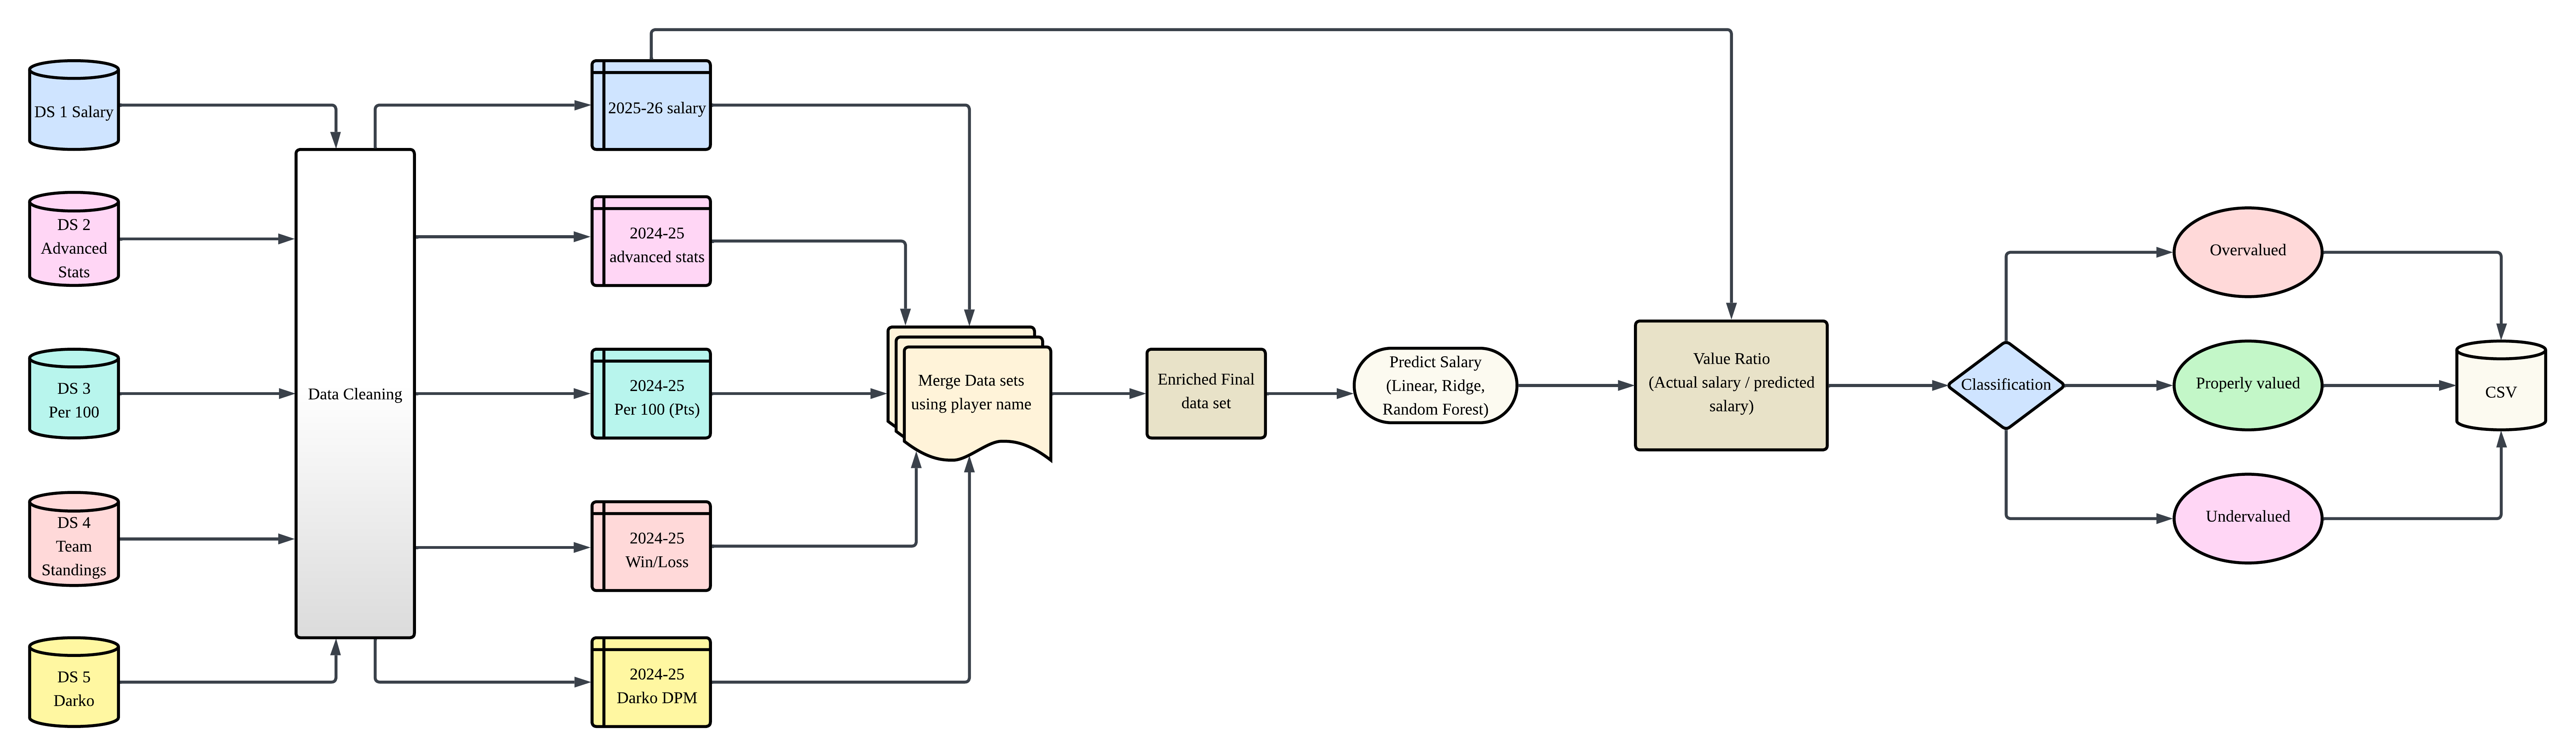

#Requirement Analysis

To systematically identify NBA player valuation inefficiencies, we require comprehensive data encompassing both financial compensation and on-court performance. Specifically, we use 2025-26 season salary data for all NBA players, which serves as our target variable for analysis. This must be paired with advanced performance statistics DPM (Darko) from the preceding 2024-25 season and including the following key metrics:


*   **BPM (Box Plus/Minus):** Overall player impact per 100 possessions
*   **VORP (Value Over Replacement Player):** Total value contributed above a replacement-level player
*   **TS% (True Shooting Percentage):** Comprehensive shooting efficiency metric
*   **PTS/100:** Scoring volume adjusted for pace of play
*   **OBPM/DBPM:** Offensive and defensive components of overall impact
*   **DPM (DARKO)** NBA box score and impact projection system




To address the objective, we require:

1. **Market price data**

*    Player Salary_2025 (target variable) for the 2025–26 season.


2. **Player performance data**

*   2024–25 metrics relevant to offensive/defensive and total impact, including: PTS, TS%, OBPM, DBPM, BPM, VORP, MP, DPM (DARKO).

3. **Team context data**


*   Team standings to compute Team_Win_Pct for win-alignment comparison.

4. **Data quality and preparation requirements**
*   Remove invalid salary entries (0 or empty).
*   Filter low-sample players (MP <= 100).
*   Resolve duplicate player rows (trades/multi-team rows).
*   Standardize player and team identifiers for joining.
*   Handle remaining missing values (for example imputation).







#**PREPARE**

## **Links of Considered Sources**


##Adavanced Statistics (BPM, VORP, TS%, OBPM, DBPM)

*   https://www.basketball-reference.com/leagues/NBA_2025_advanced.html

##Per 100 Possesion Satistics

*   https://www.basketball-reference.com/leagues/NBA_2025_per_poss.html



##Player Salary

*   https://www.basketball-reference.com/contracts/players.html

## Team Standings


*   https://www.basketball-reference.com/leagues/NBA_2025_standings.html

## DARKO
*   https://apanalytics.shinyapps.io/DARKO/_w_09178c26f7b1429a87786407207360ac/#tab-3852-7






## **Source Selection Justification**

 **Comprehensive :** Complete NBA player coverage, including salary, player performance, team-outcome context, and an independent impact signal.

 **Reliable :** Industry-standard basketball statistics

 **Structured :** Well-organized data tables

 **Joinability :** Compatible identifiers (Player, Team/Tm) support deterministic merges.

 **Accessible :** CSV export and web scraping friendly

**Updated :** Sources are maintained and regularly refreshed.


## **Sources Considered but Rejected**


### 1) NBA.com


*   www.nba.com/stats




> Rejected because data extraction is less reproducible for this project (UI-driven retrieval), and many available tables are outside our scope.




### 2) Basketball-Reference Totals and Per-Game Tables
- https://www.basketball-reference.com/leagues/NBA_2026_totals.html
- https://www.basketball-reference.com/leagues/NBA_2026_per_game.html



> Rejected for feature selection reasons. We chose per-100 and advanced metrics instead, because they better normalize pace/playing-time effects and are more suitable for valuation comparability.




### 3) DunksAndThrees (EPM)
- https://dunksandthrees.com/epm

> High analytical value, but full data access is constrained (paywall/download restrictions), limiting reproducibility for the full class workflow.


### 4) Cleaning the Glass
- https://cleaningtheglass.com/

> Rich contextual metrics, but key data is access-restricted (paywall), so extraction is not fully reproducible for this project.


### 5) DataBallr
- https://databallr.com/

> Contains valuable advanced metrics like DARKO and lineup data, but extraction workflow is not sufficiently reproducible for our pipeline constraints.



---


These alternatives were useful but the final accepted sources prioritized reproducibility, transparency, and deterministic joins.


## **Before runing the code**

1. Open the shared Drive folder link.
2. Click “Add shortcut to Drive” (put it in My Drive).
3. Open the Colab and run the first cell


## **Google drive Link**

https://drive.google.com/drive/folders/1b4lcv7p7ta9ZVc-b1wS_NYudHHnB5S8Z?usp=sharing

In [ ]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

# Change this to your project folder name in MyDrive
DATA_DIR = "/content/drive/MyDrive/SC3021_NBA Datasets"

required_files = [
    "NBA_Player_Salary.csv",
    "NBA_2025_advanced.csv",
    "NBA_2025_per_poss.csv",
    "NBA_Team_Standings_2025.csv",
    "DARKO_Player_Stats.csv"
]

missing = [f for f in required_files if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(f"Missing files: {missing}")

# Read files
#changing of file name will not work. please check naming convention is same as listed here
salaries = pd.read_csv(f"{DATA_DIR}/NBA_Player_Salary.csv", header=1)
df_advanced = pd.read_csv(f"{DATA_DIR}/NBA_2025_advanced.csv")
df_per100 = pd.read_csv(f"{DATA_DIR}/NBA_2025_per_poss.csv")
df_team_standings = pd.read_csv(f"{DATA_DIR}/NBA_Team_Standings_2025.csv")
df_darko = pd.read_csv(f"{DATA_DIR}/DARKO_Player_Stats.csv")


#--------------------------------------------------------------------------
# AI - CODEX
# Assisted by to setup the Google Mount to read the data or the csv files
#---------------------------------------------------------------------------



# **Dataset Exploration & Collection**

## **DataSet 1 : NBA Player Salary from  Basketball Reference**

**Description:** This dataset contains NBA player salary information for the 2025-26 season and beyond from Basketball-Reference. It includes current and future contract details and provides the financial target needed for valuation analysis. In this project, we use the 2025-26 salary field. The code below imports the data into a DataFrame and displays the first rows.

In [ ]:
import pandas as pd
import numpy as np

# DATA COLLECTION: SALARIES 2025-26

salaries = pd.read_csv(f"{DATA_DIR}/NBA_Player_Salary.csv", header=1)
print("\n salary data (first 5 rows):")
print (salaries.head(5))


## **DS 1 : Salaries Metadata**

**Exploration:** Inspected structure with `.head()` and `.info()`, checked contract year salary fields, and indentified player level duplicates before cleaning.

**Quality Consideration:**

*   **Completeness:** `Player` and salary fields are mostly present, but some rows contain blank or zero salary values.
*   **Accuracy:** Salary values are stored as currency-formatted strings and require normalization in the Process section.


*   **Reputation:** Basketball-Reference is a widely used public source in sports analytics and aligns with our other Basketball-Reference tables.
*  **Timeliness:** Highly current; reflects active 2025–26 salary figures including mid-season trades and signings.


**Conclusion:** Accepted as the salary source for further cleaning and modeling. Quality issues identified here are handled in Process.



In [ ]:
print(salaries.info())

## **DataSet 2 : Advanced Statistics from  Basketball Reference**

**Description:** This dataset contains advanced performance metrics for NBA players during the 2024-25 regular season, sourced from Basketball-Reference. These metrics provide richer player impact signals beyond traditional box-score statistics. The code below imports the data into a DataFrame and displays the first rows.

In [ ]:
# DATA COLLECTION: ADAVANCED STATS

df_advanced = df_advanced = pd.read_csv(f"{DATA_DIR}/NBA_2025_advanced.csv")
print("\n Advanced stats data (first 5 rows):")
print("\n")
print(df_advanced.head(5))

print(df_advanced.columns.tolist())

## **DS 2 : Advanced Stats Metadata**

**Exploration:** We checked `.head()` and `.info()` and confirmed required columns exist like (`TS%`, `OBPM`, `DBPM`, `BPM`, `VORP`) which is more important later part modelling.  

**Quality Considerations:**  
* **Completeness:** Required advanced stats are available for most players.  
* **Accuracy:** Metrics follow standard Basketball-Reference definitions.  
* **Reputation:** Commonly used source for NBA analysis.  
*  **Timeliness:** Reflects the most recent fully completed season `(2024–25)`, providing a finalized baseline for analysis.  

**Conclusion:** : Essential for identifying "underrated" players whose impact exceeds their basic box score stats. Accepted as core performance input.

In [ ]:
print(df_advanced.info())

## **DataSet 3 : NBA Player Per 100 Possesion Statistics from  Basketball Reference**

**Description:** This dataset contains pace-adjusted statistics (per 100 possessions) for the 2024-25 regular season. These metrics normalize for pace and improve comparability across teams and roles. The code below imports the data into a DataFrame and displays the first rows.


In [ ]:
# DATA COLLECTION: PER 100 POSSESION STATS

df_per100 = pd.read_csv(f"{DATA_DIR}/NBA_2025_per_poss.csv", header= 0)
print("\n Per 100 Possession stats data (first 5 rows):")
print("\n")
print(df_per100.head(5))


## **DS 3: Per 100 Possessions Stats Metadata**

**Exploration:** We reviewed `.head()` and `.info()` and confirmed `Player` + needed metrics like `PTS`.  

**Quality Considerations:**  
- **Completeness:** Key fields are present for most players.  
- **Accuracy:** Per-100 format improves fair comparison across pace differences.  
- **Reputation:** Basketball-Reference per-possession stats are standard.  
- **Timeliness:** Finalized `2024–25` dataset allows for comparison against historical league-wide averages.  


**Conclusion:** The most fair way to compare player's scoring and rebounding rates across different team systems. Accepted as a useful complement to advanced stats.

In [ ]:
print(df_per100.info())

##**DS 4: Team standings**

The Basketball-Reference Team Standings dataset provides a seasonal snapshot of NBA team performance by conference and division. It includes core metrics such as wins, losses, and win percentage (`W/L%`). The code below imports the data and displays the first rows.

In [ ]:
#Team Standings

df_team_standings = pd.read_csv(f"{DATA_DIR}/NBA_Team_Standings_2025.csv")
print("\n NBA Team Win/Loss stats data (first 5 rows):")
print("\n")
print(df_team_standings.head(5))

## **DS 4: Team Satndings Metadata**

**Exploration:** We checked `.head()` and `.info()` and confirmed needed fields (`Team`, `W`, `L`, `W/L%`).


**Quality Considerations:**  
- **Completeness:** Full league team coverage is present.  
- **Accuracy:** Win/loss stats are direct and low-ambiguity.  
- **Reputation:** Basketball-Reference standings are widely trusted.  
- **Timeliness:** Highly relevant as a finalized historical record. Since the `2024–25` season concluded on April 13, 2025, this dataset provides complete and unchangeable data for analysis.  


**Conclusion:** This is the definitive dataset for analyzing team dominance during the `2024–25` cycle and serves as the baseline for evaluating which teams over or under performed relative to their rosters. Accepted for team context (`Team_Win_Pct`) enrichment.

In [ ]:
print(df_team_standings.info())

## **DS 5: DARKO**

The DARKO (Daily Adjusted and Regressed Kalman Optimized) dataset is a machine learning-driven NBA player projection system created by Kostya Medvedovsky. Unlike traditional backward-looking stats, it uses Kalman filtering to provide a forward-looking estimate of a player's current talent and future performance. The dataset features DPM (Daily Plus-Minus), which measures a player's impact per 100 possessions by integrating box scores, tracking data, and play-by-play information.

In [ ]:
# DATA COLLECTION: DARKO

df_darko = pd.read_csv(f"{DATA_DIR}/DARKO_Player_Stats.csv")
print("\n Darko data (first 5 rows):")
print (df_darko.head(5))


## **DS 5: DARKO DPM Metadata**

**Exploration:** We checked `.head()` and `.info()` and confirmed `Player` and `DPM` (Daily Plus-Minus) fields for offensive and defensive impact.

**Quality Considerations:**  
- **Completeness:** Covers nearly all active players, eventhough the naming conventions often differ from Basketball-Reference, requiring a join-audit.
- **Accuracy:** Adds an independent impact signal beyond Basketball-Reference stats.  
- **Reputation:** Highly regarded; DARKO is an industry-standard metric trusted by professional analysts for its ability to predict future performance better than raw box-score stats.  
- **Timeliness:** Updated daily throughout the season, providing a real-time skill estimate that accounts for a player's most recent games.

**Conclusion:** Accepted with join-audit, name-normalization and it provides a necessary independent impact signal.

In [ ]:
print(df_darko.info())

# **PROCESS**

##**Data Cleaning**

##**DS 1 : NBA Player Salary Data Cleaning**

In [ ]:
#removing " $ " and " , "
def clean_salary(salary_str):
  if pd.isna(salary_str) or salary_str == ' ':
    return 0

  salary_str = str(salary_str)
  salary_str = salary_str. replace('$' , '').replace(',' , '').strip()
  if salary_str == ' ' or salary_str == '0' :
    return 0
  try:
    return int(float(salary_str))
  except:
    return 0

salaries['Salary_2025'] = salaries['2025-26']. apply(clean_salary)

print(salaries.head())
print("\n" "\n" f" Total player in Salary Dataset: {len(salaries)}")




Check for player salaries with `0` or empty values in the `Salary_2025` column.

In [ ]:
#remove players Salary 0 or empty
salaries = salaries[salaries['Salary_2025'] > 0].copy()

print(f" Total player in Salary Dataset after removing EMPTY OR 0 : {len(salaries)}")

Check for duplicates because some players may have played for two different teams (traded mid season) in the same season.

In [ ]:
#check for duplicate players
try:
  Player_duplicate = salaries.duplicated(subset= ['Player'], keep= False)
  Duplicate_compare = salaries[Player_duplicate].sort_values(['Player', 'Salary_2025'], ascending= [True, False])
  print(Duplicate_compare)
except Exception as e:
  print("No Duplicates found")



Remove duplicates by sorting salary in descending order and keeping the highest-salary row. In this dataset, most duplicate-player rows have the same salary even when the player appears under two teams, so deduplicating by player name after sorting is appropriate.

In [ ]:
# Remove Duplicates
# This keeps the highest salary if dupicates exist

rows_before = len(salaries)
salaries = salaries.sort_values('Salary_2025', ascending = False).drop_duplicates(subset= 'Player')
rows_after = len(salaries)
print(f" Removed {rows_before - rows_after} duplicate rows")

Summary after cleaning the salary dataset (duplicate removal + invalid `Salary_2025` handling).

In [ ]:
print(" 2025-26 Player Salary Summary")
print("\n")
print(f" Total player in Salary Dataset: {len(salaries)}")
print("\n")
print(f" Minimum: ${salaries['Salary_2025'].min():,}")
print(f" Maximum: ${salaries['Salary_2025'].max():,}")
print(f" Avergae: ${salaries['Salary_2025'].mean():,}")

required_salary_year = ['Player', 'Tm','Salary_2025']
available_salary_year = [col for col in required_salary_year if col in salaries.columns]

display(salaries[available_salary_year].head(10))



## **DS 2 : Advanced Statistics Data Cleaning**

In [ ]:
#if the dataset had multilevel header
if isinstance(df_advanced.columns, pd.MultiIndex):
  df_advanced.columns = df_advanced.columns.droplevel(0)

print(f" Advanced stats columns: {len(df_advanced.columns)}")


In [ ]:
#selecting the metrics that needed
required_metrics_advanced = ['Player', 'Age', 'Team',  'MP', 'TS%', 'OBPM', 'DBPM', 'BPM', 'VORP']
available_metrics_advanced = [col for col in required_metrics_advanced if col in df_advanced.columns]

display(df_advanced[available_metrics_advanced].head())

## **DS 3 : Per 100 Possession Data Cleaning**

In [ ]:

print(f" Per 100 stats columns: {len(df_per100.columns)}")

In [ ]:
#selecting the metrics that needed
required_metrics_per100 = ['Player', 'PTS']
available_metrics_per100 = [col for col in required_metrics_per100 if col in df_per100.columns]

display(df_per100[available_metrics_per100].head(10))

## **DS 4: Team Standings Data Cleaning**

In [ ]:
# Clean the Team names (remove ' (1)', ' (2)' seeding markers or asterisks)
df_team_standings['Team'] = df_team_standings['Team'].str.replace(r'\s*\(\d+\)', '', regex=True).str.replace('*', '', regex=False)

# Keep only the columns needed for our validation
df_team_standings = df_team_standings[['Team', 'W', 'L', 'W/L%']]


display(df_team_standings.head(11))



##**DS 5: Darko Data Cleaning**

In [ ]:
#if the dataset had multilevel header
if isinstance(df_darko.columns, pd.MultiIndex):
  df_darko.columns = df_darko.columns(0)

print(f" DARKO columns: {len(df_darko.columns)}")
print(df_darko.columns)

In [ ]:
#selecting the metrics that needed
required_metrics_darko = ['Player','DPM']
available_metrics_darko = [col for col in required_metrics_darko if col in df_darko.columns]

display(df_darko[available_metrics_darko].head(10))

## **Data Integration**

## **Inclusion Dependency Check (Join Key Audit)**

Before each merge, we check inclusion dependency on the join key to see key compatibility between sources.

For each pair of datasets, we report:
- number of unique join keys in each source
- keys in left source with no match in right source (`Left_Only_Unmatched`)
- keys in right source with no match in left source (`Right_Only_Unmatched`)
- key coverage percentages on both sides

This helps us detect join risk early and justify merge outcomes beyond merge-rate alone.


In [ ]:

def inclusion_dependency_check(left_df, right_df, key, left_name, right_name):
    left_keys = left_df[key].dropna().astype(str).str.strip()
    right_keys = right_df[key].dropna().astype(str).str.strip()

    left_set = set(left_keys)
    right_set = set(right_keys)

    left_only = sorted(left_set - right_set)
    right_only = sorted(right_set - left_set)

    left_coverage = 100 * (len(left_set) - len(left_only)) / len(left_set) if len(left_set) else 0
    right_coverage = 100 * (len(right_set) - len(right_only)) / len(right_set) if len(right_set) else 0

    summary = pd.DataFrame([{
        'Left_Source': left_name,
        'Right_Source': right_name,
        'Join_Key': key,
        'Left_Unique_Keys': len(left_set),
        'Right_Unique_Keys': len(right_set),
        'Left_Only_Unmatched': len(left_only),
        'Right_Only_Unmatched': len(right_only),
        'Left_Coverage_%': round(left_coverage, 2),
        'Right_Coverage_%': round(right_coverage, 2)
    }])

    display(summary)

    return {
        'summary': summary,
        'left_only': left_only,
        'right_only': right_only
    }


**Merging Datasets**

Combine advanced stats and per-100 possession stats using player name as the primary key, then store the merged table as `df_stats`.

In [ ]:
#Inclusion Dependency check for Advanced stats and Per 100 stats
audit_adv_per100 = inclusion_dependency_check(
    df_advanced[available_metrics_advanced],
    df_per100[available_metrics_per100],
    key='Player',
    left_name='Advanced Stats',
    right_name='Per100 Stats'
)

In [ ]:
df_stats = pd.merge(df_advanced[available_metrics_advanced],df_per100[available_metrics_per100], on = 'Player', how = 'left')

display(df_stats.head())

print(f" \n Total number of player: {len(df_stats)}")





Removing duplicate players who switched teams

In [ ]:
try:
  df_stats = df_stats.sort_values(['Player', 'MP'], ascending = [True, False])
  df_stats = df_stats.drop_duplicates(subset ='Player', keep= 'first')

  print(f" Total No.of Players after removing duplicates: {len(df_stats)}")

except Exception as e:
  print("No Duplicates found")

In [ ]:
# checking merge rate

merge_rate = len(df_stats) / min (len(df_advanced) , len(df_per100)) * 100
print(f" Merge Rate: {merge_rate:.2f}%")

**Data Enrichment**

Filter out players with fewer than 100 minutes (`MP < 100`) to reduce low-sample noise before salary modeling.

In [ ]:
df_stats = df_stats[df_stats['MP'] >= 100].copy()
print(f" Total No.of Players after filtering out tho who played less than 100 : {len(df_stats)}")

**Merging Datasets**

Merge salary data with `df_stats` (advanced + per-100 possession stats) using player name as the primary key, and store the output as `df_performance_stats`.

In [ ]:
#Inclusion Dependency check for DF stats and Salary
audit_stats_salary = inclusion_dependency_check(
    df_stats[['Player']],
    salaries[['Player', 'Tm', 'Salary_2025']],
    key='Player',
    left_name='Performance Stats',
    right_name='Salary Table'
)

In [ ]:
#only player with both salary and performance data
df_performance_stats = pd.merge(df_stats, salaries[['Player','Tm', 'Salary_2025']], on = 'Player', how = 'inner')

display(df_performance_stats.head(15))

In [ ]:
# checking merge rate

merge_rate = len(df_performance_stats) / min (len(df_stats) , len(salaries)) * 100
print(f" Merge Rate: {merge_rate:.2f}%")

In [ ]:
print(f" Total No.of Players Final dataset : {len(df_performance_stats)}")

**Merging Datasets**

Merge team standings with player performance stats and map team `Tm` to attach `Team_Win_Pct`.

In [ ]:
# 1. Ensure team abbreviations match (e.g., 'BRK' vs 'BKN')
# Basketball-Reference uses 'BRK' for Brooklyn and 'CHO' for Charlotte.
team_map = {
    'Atlanta Hawks': 'ATL', 'Boston Celtics': 'BOS', 'Brooklyn Nets': 'BRK',
    'Charlotte Hornets': 'CHO', 'Chicago Bulls': 'CHI', 'Cleveland Cavaliers': 'CLE',
    'Dallas Mavericks': 'DAL', 'Denver Nuggets': 'DEN', 'Detroit Pistons': 'DET',
    'Golden State Warriors': 'GSW', 'Houston Rockets': 'HOU', 'Indiana Pacers': 'IND',
    'Los Angeles Clippers': 'LAC', 'Los Angeles Lakers': 'LAL', 'Memphis Grizzlies': 'MEM',
    'Miami Heat': 'MIA', 'Milwaukee Bucks': 'MIL', 'Minnesota Timberwolves': 'MIN',
    'New Orleans Pelicans': 'NOP', 'New York Knicks': 'NYK', 'Oklahoma City Thunder': 'OKC',
    'Orlando Magic': 'ORL', 'Philadelphia 76ers': 'PHI', 'Phoenix Suns': 'PHO',
    'Portland Trail Blazers': 'POR', 'Sacramento Kings': 'SAC', 'San Antonio Spurs': 'SAS',
    'Toronto Raptors': 'TOR', 'Utah Jazz': 'UTA', 'Washington Wizards': 'WAS'
}

# 2. Prepare the 4th Dataset (Standings)
# Map full names to abbreviations so they match your player data
df_team_standings['Tm'] = df_team_standings['Team'].map(team_map)
df_team_standings['Team_Win_Pct'] = df_team_standings['W'] / (df_team_standings['W'] + df_team_standings['L'])






In [ ]:
#Inclusion Dependency check for Performance + salary and Team standings

audit_team_codes = inclusion_dependency_check(
    df_performance_stats[['Tm']],
    df_team_standings[['Tm', 'Team_Win_Pct']],
    key='Tm',
    left_name='Performance+Salary Team Codes',
    right_name='Standings Team Codes'
)

In [ ]:
# 4. MERGE
df_performance_stats_withteam = pd.merge(df_performance_stats, df_team_standings[['Tm', 'Team_Win_Pct']], on='Tm', how='left')

display(df_performance_stats_withteam.head(15))

In [ ]:
# checking merge rate

merge_rate = len(df_performance_stats_withteam) / len(df_performance_stats) * 100
print(f" Merge Rate: {merge_rate:.2f}%")

In [ ]:
print(len(df_performance_stats_withteam))

**Merging Datasets**

Merge the standings-enriched table with DARKO stats using player name as the primary key, and store it as `df_performance_stats_withdarko`.

### Inclusion Dependency Check (Before Name Normalization)

Using `Player` as the join key between Performance+Team and DARKO:

- Performance+Team unique players: 389
- DARKO unique players: 526
- Left-only unmatched: 35
- Right-only unmatched: 172
- Left coverage: 91.0%
- Right coverage: 67.3%

This confirms join-key mismatch before normalization. Sample unmatched names (e.g., `Alperen Şengün` vs `Alperen Sengun`) show cross-source naming differences.


Because DARKO is from a different provider, we run the same inclusion check before and after name normalization to quantify match improvement.


In [ ]:
#Inclusion Pre Dependency check for Perfomance stats with team and DARKO

audit_darko_pre = inclusion_dependency_check(
    df_performance_stats_withteam[['Player']].copy(),
    df_darko[['Player']].copy(),
    key='Player',
    left_name='Performance stats with Team',
    right_name='DARKO'
)

Since DARKO is from a different source, player names may vary. We normalize names to match Basketball-Reference naming so we do not lose rows during merging.

In [ ]:
import pandas as pd
import re

def clean_nba_name(name_series):
    return (name_series
            .str.normalize('NFKD')            # Decompose accents
            .str.encode('ascii', 'ignore')   # Removes the accents
            .str.decode('utf-8')               # Convert back to string
            #.str.lower()                       # Standardize case
            .str.replace(r'\s+(jr|sr|iii|iv|ii|111)$', '', regex=True, flags=re.IGNORECASE) # Remove suffixes
            .str.replace(r'[.\']', '', regex=True) # Remove dots (P.J. -> pj)
            .str.strip())

# Create the temporary join keys
df_performance_stats_withteam['Player'] = clean_nba_name(df_performance_stats_withteam['Player'])
df_darko['Player'] = clean_nba_name(df_darko['Player'])


### Inclusion Dependency Post Check (Performance+Team vs DARKO)

Using `Player` as the join key:
- Performance+Team unique players: 389
- DARKO unique players: 526
- Left-only unmatched (Performance+Team not in DARKO): 20
- Right-only unmatched (DARKO not in Performance+Team): 157
- Left coverage: 94.86%
- Right coverage: 70.15%

This shows most players in our integrated table match DARKO, while unmatched keys remain due to provider naming differences and source-scope differences.


In [ ]:
#Inclusion Post Dependency check for Perfomance stats with team and DARKO

audit_darko_post = inclusion_dependency_check(
    df_performance_stats_withteam[['Player']].copy(),
    df_darko[['Player']].copy(),
    key='Player',
    left_name='Performance+Team (normalized names)',
    right_name='DARKO (normalized names)'
)

In [ ]:
# merging
df_performance_stats_withdarko = pd.merge(df_performance_stats_withteam, df_darko[required_metrics_darko], on='Player', how='left', indicator=True)
print(df_performance_stats_withdarko.head(15))

In [ ]:
#checking merge rate
merge_rate = len(df_performance_stats_withdarko) / len(df_performance_stats_withteam) * 100
print(f" Merge Rate: {merge_rate:.2f}%")
print(len(df_performance_stats_withdarko))


In [ ]:
df_final_dataset = df_performance_stats_withdarko
display(df_final_dataset.head(20))
print()

The `_merge` column is retained as a merge-audit field to verify how DARKO rows matched with Basketball-Reference rows.



Before Mean Impution `DPM` columns for players missing DPM stats

In [ ]:
# Filter for players who have NaN in a Darko-specific column (e.g., 'darko_rating')
missing_in_darko = df_final_dataset[df_final_dataset['DPM'].isna()]

# View the list of names to check for any remaining naming inconsistencies
print(missing_in_darko['Player'].unique())

only_in_perf = df_final_dataset[df_final_dataset['_merge'] == 'left_only']
print(len(only_in_perf))

### **Impact of Mean Imputation on Unmatched DARKO Players**

After name normalization, 20 players still had no DARKO match (`20/389 = 5.1%`), so their `DPM` was imputed using the dataset mean.

This keeps those players in the dataset and avoids dropping salary rows, but it reduces player-specific variation for those 20 players.  
So the effect is likely small at league level, but player-level valuation near category cutoffs may change.


In [ ]:
# Create the binary indicator
#df_final_dataset['is_missing_dpm'] = df_final_dataset['DPM'].isna().astype(int)

# Fill NaNs with the mean (prevents the 'zero' outlier issue)
dpm_mean = df_final_dataset['DPM'].mean()
df_final_dataset['DPM'] = df_final_dataset['DPM'].fillna(dpm_mean)


After Mean Impution `DPM` columns for players missing DPM stats. Now there are no players with missing `DPM` stats.

In [ ]:
# Filter for players who have NaN in a Darko-specific column (e.g., 'darko_rating')
missing_in_darko = df_final_dataset[df_final_dataset['DPM'].isna()]

# View the list of names to check for any remaining naming inconsistencies
print(missing_in_darko['Player'].unique())

In [ ]:
df_final_dataset.to_csv('Final Dataset.csv', index = False)

In [ ]:
print(df_final_dataset.info())

## **Data Set Quality Check (Completeness, Consistency)**

Final check of our Final Dataset to ensure there no missing value because missing values tends to create inaccurate calculations when the data fed into the models and perform checks for completeness, consistency, and merge integrity before modeling.





In [ ]:
quality_columns = ['Salary_2025', 'Age', 'MP', 'TS%', 'PTS', 'OBPM', 'DBPM', 'BPM', 'VORP', 'DPM', 'Team_Win_Pct']
# Completeness report
missing_report = pd.DataFrame({
    'Missing_Count': df_final_dataset[quality_columns].isna().sum(),
    'Missing_Rate_%': (df_final_dataset[quality_columns].isna().mean() * 100).round(2)
}).reset_index().rename(columns={'index': 'Column'})

print(f" Total No.of Payers in the final dataset : {len(df_final_dataset)}")
display(missing_report)

In [ ]:
# Consistency check for duplicate players
duplicate_players = df_final_dataset.duplicated(subset=['Player']).sum()
print(f"Duplicate players in final dataset: {duplicate_players}")

In [ ]:
display(df_final_dataset.head(11))

## **Distribution Re-Profiling After Integration**


After merging all sources, we re-profiled the final dataset by:
- reviewing descriptive statistics (`.describe()` with percentiles), and
- plotting histograms (with KDE) for key variables: `Salary_2025`, `Age`, `MP`, `TS%`, `PTS`, `VORP`, `DPM`, and `Team_Win_Pct`.

This provides a distribution check beyond missing-value validation and confirms the merged dataset is suitable for modeling.









In [ ]:
profile_cols = ['Salary_2025', 'Age', 'MP', 'TS%', 'PTS', 'OBPM', 'DBPM', 'BPM', 'VORP', 'DPM', 'Team_Win_Pct']

distribution_profile = df_final_dataset[profile_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(distribution_profile.round(3))




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_cols = ['Salary_2025', 'Age', 'MP', 'TS%', 'PTS', 'VORP', 'DPM', 'Team_Win_Pct']
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(df_final_dataset[col], bins=25, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col} Distribution')

print("\n")
plt.tight_layout()
plt.savefig('Final_DataSet_distribution.png')
plt.show()
print("Visualisations saved as 'Final_DataSet_distribution.png' ")


#-----------------------------------
# AI Assisted for visualisation (CODEX)
#----------------------------------


# **ANALYZE**

## **Final Dataset Design and Justification**

Our final dataset is designed to connect the three core elements of this project in one player-level table:

- **Market price**: `Salary_2025` (what the NBA market pays)
- **Player contribution**: `PTS`, `TS%`, `OBPM`, `DBPM`, `BPM`, `VORP`, `DPM`
- **Winning context**: `Team_Win_Pct`

### Why these columns were kept
- **Identifiers**: `Player`, `Team`, `Tm` for consistent joining and traceability.
- **Controls**: `Age`, `MP` to account for career stage and opportunity/sample size.
- **Core analytics fields**: salary + selected performance and impact metrics.
- **Data-audit field**: `_merge` to track merge completeness and source matching quality.

### Why this structure is suitable
This structure allows direct comparison between:
1. how strongly a metric is associated with **salary**, and
2. how strongly the same metric is associated with **team winning**,

which is exactly the requirement for our bias analysis using correlation-delta.


## **Operational Definitions**


- **Bias for metric m**: `Delta_r(m) = corr(m, Salary) - corr(m, Team_Win_Pct)`
- **Overvaluation signal**: `Delta_r(m) > 0` the metric is more strongly associated with **salary** than with **wins**.
- **Undervaluation signal**: `Delta_r(m) < 0` the metric is more strongly associated with **wins** than with **salary**.

- **Player-level Classification**

  `Value_Ratio = Salary / Predicted_Market_Value`
  

*   `< 0.8 = Undervalued`
*   `0.8 to 1.2 = Fairly valued`
*   `> 1.2 = Undervalued`


These are diagnostic definitions for this project dataset, not universal NBA truths.

## **Bias Inheritence and Modelling Logic**

**Key concern:** Salary labels can contain market bias. A model trained on salary can learn and reproduce that bias.

How this project handles it:
1. `Predicted_Market_Value` is treated as a **market mirror**, not objective truth.
2. Bias signals are evaluated using descriptive correlation-delta:
`Delta_r(m) = corr(m, Salary) - corr(m, Team_Win_Pct)`.
3. Player valuation categories use fixed decision thresholds (`Value_Ratio` bins: `[0, 0.8, 1.2, inf]`) for interpretability and comparability.
4. Conclusions are framed as sample-based associations within this dataset and setup, not universal causal claims.

## **Exploratory Data Analysis & Data Visualization**

In [ ]:
print("Dataset overview:-")
print(f" Total Players: {len(df_final_dataset)}")

print("\n Performance Satistics Summary:")
df_final_dataset.describe()




Visualizations transform numbers into insights. Below are six key plots that summarize relationships between salary and performance:


### 1. Salary Distribution
Shows how NBA salaries are distributed across players, with a small number of max contracts and many lower-salary contracts.

### 2. Salary vs BPM (Box Plus/Minus)
Shows the relationship between overall player impact and compensation.

### 3. Salary vs VORP (Value Over Replacement Player)
Shows how cumulative value contribution is related to salary.

### 4. Salary vs Scoring (PTS/100)
Shows the premium placed on scoring volume in salary outcomes.

### 5. Salary vs Efficiency (TS%)
Shows how shooting efficiency relates to pay.

### 6. Correlation Heatmap
Provides an overall view of how metrics interrelate and which factors are most associated with salary.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('NBA Player Performance vs Salary Analysis (2023-24 Stats vs 2024-25 Salary)',
             fontsize=16, fontweight='bold')

#1. Salary distribution
axes[0, 0].hist(df_final_dataset['Salary_2025'] / 1e6, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Salary ($ Millions)')
axes[0, 0].set_ylabel('Number of Players')
axes[0, 0].set_title('Distribution of NBA Salaries')
axes[0, 0].axvline(df_final_dataset['Salary_2025'].mean() / 1e6, color='red', linestyle='--',
                   label=f'Mean: ${df_final_dataset["Salary_2025"].mean()/1e6:.1f}M')
axes[0, 0].legend()

# 2. Salary vs BPM (Main performance metric)
axes[0, 1].scatter(df_final_dataset['BPM'], df_final_dataset['Salary_2025'] / 1e6, alpha=0.6)
axes[0, 1].set_xlabel('BPM (Box Plus/Minus)')
axes[0, 1].set_ylabel('Salary ($ Millions)')
axes[0, 1].set_title('Salary vs BPM')
z = np.polyfit(df_final_dataset['BPM'], df_final_dataset['Salary_2025'] / 1e6, 1)
p = np.poly1d(z)
axes[0, 1].plot(df_final_dataset['BPM'].sort_values(), p(df_final_dataset['BPM'].sort_values()),
                "r--", alpha=0.8)

#3. Salary vs VORP
axes[0, 2].scatter(df_final_dataset['VORP'], df_final_dataset['Salary_2025'] / 1e6, alpha=0.6, color='green')
axes[0, 2].set_xlabel('VORP (Value Over Replacement Player)')
axes[0, 2].set_ylabel('Salary ($ Millions)')
axes[0, 2].set_title('Salary vs VORP')
z = np.polyfit(df_final_dataset['VORP'], df_final_dataset['Salary_2025'] / 1e6, 1)
p = np.poly1d(z)
axes[0, 2].plot(df_final_dataset['VORP'].sort_values(), p(df_final_dataset['VORP'].sort_values()),
                "r--", alpha=0.8)

# 4. Salary vs PTS/100
axes[1, 0].scatter(df_final_dataset['PTS'], df_final_dataset['Salary_2025'] / 1e6, alpha=0.6, color='purple')
axes[1, 0].set_xlabel('Points per 100 Possessions')
axes[1, 0].set_ylabel('Salary ($ Millions)')
axes[1, 0].set_title('Salary vs Scoring Volume')
z = np.polyfit(df_final_dataset['PTS'], df_final_dataset['Salary_2025'] / 1e6, 1)
p = np.poly1d(z)
axes[1, 0].plot(df_final_dataset['PTS'].sort_values(), p(df_final_dataset['PTS'].sort_values()),
                "r--", alpha=0.8)

# 5. Salary vs TS% (Efficiency)
axes[1, 1].scatter(df_final_dataset['TS%'], df_final_dataset['Salary_2025'] / 1e6, alpha=0.6, color='orange')
axes[1, 1].set_xlabel('True Shooting Percentage (TS%)')
axes[1, 1].set_ylabel('Salary ($ Millions)')
axes[1, 1].set_title('Salary vs Shooting Efficiency')
z = np.polyfit(df_final_dataset['TS%'], df_final_dataset['Salary_2025'] / 1e6, 1)
p = np.poly1d(z)
axes[1, 1].plot(df_final_dataset['TS%'].sort_values(), p(df_final_dataset['TS%'].sort_values()),
                "r--", alpha=0.8)

# 6. Correlation Heatmap
corr_data = df_final_dataset[['Salary_2025', 'BPM', 'VORP', 'TS%', 'PTS', 'OBPM', 'DBPM']].corr()
im = axes[1, 2].imshow(corr_data, cmap='coolwarm', aspect='auto')
axes[1, 2].set_title('Correlation Heatmap')
axes[1, 2].set_xticks(range(len(corr_data.columns)))
axes[1, 2].set_xticklabels(corr_data.columns, rotation=45, ha='right')
axes[1, 2].set_yticks(range(len(corr_data.columns)))
axes[1, 2].set_yticklabels(corr_data.columns)
plt.colorbar(im, ax=axes[1, 2])

print("\n")
plt.tight_layout()
plt.savefig('NBA_Analysis.png')
plt.show()
print("Visualisations saved as 'NBA_Analysis.png' ")

**Quantifying Market Bias: Offense vs. Defense**

Are front offices paying for stats that actually translate to winning?

To find out, we will calculate the Correlation Delta. This metric measures the exact gap between a stat's correlation with player salary and its correlation with team win percentage.

Formula: `r(Stat, Salary) - r(Stat, Wins)`

In [ ]:

# calculate correlation with Salary vs correlation with Wins
correlations = df_final_dataset[['Salary_2025', 'Team_Win_Pct', 'PTS', 'VORP', 'DBPM', 'OBPM', 'BPM', 'DPM']].corr()

# 1. BIAS METRIC: Correlation Delta (Δr)
# Formula: r(Stat, Salary) - r(Stat, Wins)
bias_summary = pd.DataFrame({
    'Metric': ['PTS', 'VORP', 'DBPM', 'OBPM', 'BPM', 'DPM'],
    'Salary_Correlation': [correlations.loc['PTS', 'Salary_2025'],
                           correlations.loc['VORP', 'Salary_2025'],
                           correlations.loc['DBPM', 'Salary_2025'],
                           correlations.loc['OBPM', 'Salary_2025'],
                           correlations.loc['BPM', 'Salary_2025'],
                           correlations.loc['DPM', 'Salary_2025']],

    'Win_Correlation': [correlations.loc['PTS', 'Team_Win_Pct'],
                        correlations.loc['VORP', 'Team_Win_Pct'],
                        correlations.loc['DBPM', 'Team_Win_Pct'],
                        correlations.loc['OBPM', 'Team_Win_Pct'],
                        correlations.loc['BPM', 'Team_Win_Pct'],
                        correlations.loc['DPM', 'Team_Win_Pct']]
})
bias_summary['Correlation_Delta'] = bias_summary['Salary_Correlation'] - bias_summary['Win_Correlation']

print("BIAS EVIDENCE: SCORING VS. WINNING")
print(bias_summary)


The results above provide **descriptive evidence of market pricing asymmetry** in this sample.

**The Scoring Premium:** Points (`PTS`) and Offensive Box Plus-Minus (`OBPM`) show stronger positive association with salary than with team win percentage.

**The Defensive Inefficiency:** Defensive Box Plus-Minus (`DBPM`) shows stronger association with team win percentage than with salary.

**Conclusion:** In this sample, the market appears to reward offensive volume signals more consistently than defense-aligned winning impact.

In [ ]:
#plotting quatifying market bias

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=bias_summary,
    x='Win_Correlation',
    y='Salary_Correlation',
    s=200, # dot size
    color='blue',
    edgecolor='black'
)

# Add reference line (Fair Value Line)
plt.plot([-0.1, 0.7], [-0.1, 0.7], color= 'red', linestyle=  '--' , label = 'Fair Value (Correlation Match)')


for i in range(bias_summary.shape[0]):
    plt.text(
        bias_summary['Win_Correlation'][i] + 0.015,
        bias_summary['Salary_Correlation'][i] - 0.01,
        bias_summary['Metric'][i],
        fontsize=12, weight='bold'
    )

plt.title('NBA Market Bias: Salary vs. Winning Contribution', fontsize=16, weight='bold')
plt.xlabel('Correlation with Team Win Percentage (Impact)', fontsize=12)
plt.ylabel('Correlation with Player Salary (Pay)', fontsize=12)
plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
# Sort the dataframe by the Delta
df_sorted = bias_summary.sort_values('Correlation_Delta', ascending=True)

plt.figure(figsize=(10, 6))

# Create colors: Red for negative (Underpaid relative to wins), Green for positive (Overpaid)
colors = ['red' if x < 0 else 'green' for x in df_sorted['Correlation_Delta']]

bars = plt.barh(df_sorted['Metric'], df_sorted['Correlation_Delta'], color=colors, edgecolor='black')

plt.title(r'The NBA Pay Bias: $\Delta$ between Salary and Win Correlation', fontsize=16, weight='bold')
plt.xlabel('Correlation Delta (Salary r - Win r)', fontsize=12)
plt.axvline(0, color='black', linewidth=1.5)

# Add the text values to the ends of the bars

plt.bar_label(bars, fmt='%.3f', padding=3, weight='bold')


plt.xlim(-0.5, 0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## **Model Initialization (XGBoost, Random Forest, Linear, Ridge, Quantile)**

## **Feature Selection Rationale and Stat Relationships**

We started from a wider candidate set, but selected a compact modeling subset to reduce redundancy and improve interpretability.

### Important stat relationships (overlap/redundancy)
- `BPM = OBPM + DBPM`
- `WS = OWS + DWS`
- `WS/48 = WS / (MP/48)` (rate form of WS)
- `DPM = O-DPM + D-DPM`
- `TS% = PTS / (2 * (FGA + 0.44*FTA))`
- `3PAr = 3PA / FGA`
- `FTr = FTA / FGA`
- `VORP` is derived from BPM with playing-time/season scaling

Because many metrics are composites or transformations of others, using all of them together can double-count similar signal and increase multicollinearity.

### Chosen model features and justification
We use:
`Age`, `Age_Squared`, `MP`, `TS%`, `PTS`, `VORP`, `DPM`, `Team_Win_Pct`

- **Age + Age_Squared**: captures non-linear career value curve (prime vs decline).
- **MP**: controls for role and low-minute noise.
- **PTS + TS%**: captures scoring volume and scoring efficiency.
- **VORP**: captures total season value above replacement.
- **DPM**: adds independent all-in-one impact signal from DARKO.
- **Team_Win_Pct**: includes winning context for alignment analysis.

This compact set balances predictive signal, stability, and explainability for valuation decisions.


## Model Strategy and Selection Rationale

To avoid relying on a single modeling assumption, we train and compare multiple regression models:

- XGBoost Regressor
- Random Forest Regressor
- Linear Regression
- Ridge Regression
- Quantile Regression (median)

### Why compare multiple models
Different models capture different patterns (linear vs non-linear, regularized vs non-regularized, mean-target vs median-target).  
Comparing them improves methodological rigor and reduces the risk of selecting a model based on convenience.

### Model selection rule
We evaluate models using out-of-sample test metrics:

- **MAE**
- **RMSE**
- **R²**
- **Median Absolute Error (MedAE)**

The primary model is selected based on best overall error performance (especially MedAE/MAE), with R² used as supporting context.

### Role of Quantile Regression
Quantile regression is included as a robustness model because it targets the median and is less sensitive to extreme salary outliers.  
It serves as a stability check, while the final primary model is chosen from full metric comparison.

### Practical interpretation
The selected model’s predictions are treated as **Predicted_Market_Value** (a market mirror), not objective truth.  


These predictions are then used for value-ratio classification and market inefficiency analysis.


In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import QuantileRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



**Why we implimented `Age_Squared` ?** **(Enriching)**

Standard linear models assume a straight-line relationship, meaning each additional year of age changes value by the same amount.

NBA careers often follow an inverted U-shape: performance and market value usually peak in the mid-to-late 20s and decline later.

Adding a squared term allows the model to learn a curve instead of a straight line, helping it represent prime-vs-decline effects more realistically.






---





>  ---- We added Age Squared with of help AI (Gemini) - Idea Generation Only -----


---





In [ ]:
df_final_dataset['Age_Squared'] = df_final_dataset['Age'] ** 2
display(df_final_dataset.head())

In [ ]:
#Chosen feature for model training
features = ['Age','Age_Squared','MP','TS%', 'PTS', 'Team_Win_Pct', 'DPM', 'VORP']
available_features = [f for f in features if f  in df_final_dataset.columns]

x = df_final_dataset[available_features]
y = df_final_dataset['Salary_2025']




Training the model on all 392 players and then tested it on those same players, the model could just **"memorize"** the names and stats (this is called **overfitting**). By keeping some players hidden until the end, you get a true measure of how the model performs on new, unknown data.

In [ ]:
#split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 42)
print(f" Training Set Size = {len(x_train)} Players")
print(f" Testing Set Size = {len(x_test)} Players")
print(f" Features used: {available_features}")

Without scaling the model, might think certain selected stats is more important is simply because of the bigger numbers. So scaling puts them on the level so that the model focuses on actual impact of the stats rather than size of the numbers.

In [ ]:
#Scaling
#only numericals
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:



# 1. Models dictionary
Models = {
    'XGBoost Regression' : XGBRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Quantile (Median)': QuantileRegressor(quantile=0.5, alpha=0, solver='highs')
}

print("Training Models...")

results = []
test_predictions = {}

for name, model in Models.items():
    model.fit(x_train_scaled, y_train)
    y_predictions = model.predict(x_test_scaled)
    test_predictions[name] = y_predictions

    # Standard metrics to evaluate the models
    mae = mean_absolute_error(y_test, y_predictions)
    rmse = np.sqrt(mean_squared_error(y_test, y_predictions))
    r2 = r2_score(y_test, y_predictions)
    med_ae = median_absolute_error(y_test, y_predictions) #Median Error (ignores the superstar "outlier" bias)
    unrealistic = (y_predictions < 1_157_153).sum() #How many predictions are below the $1,157,153M NBA minimum?


    results.append({
        'Model Name': name,
        'MAE': mae,
        'RMSE': rmse,
        'MedAE': med_ae,
        'R^2': r2,
        'Unrealistic': unrealistic,
    })

df_results = (
    pd.DataFrame(results)
    .sort_values(by=['MedAE', 'R^2'], ascending = [True, False])
    .reset_index(drop=True)
)

print("\n Model Performace Summary")
print(df_results[['Model Name','MAE','RMSE','R^2','MedAE','Unrealistic']].to_string(index = False))




In [ ]:
#use best Model
best_model_name = df_results.loc[df_results['R^2'].idxmax(), 'Model Name']
best_model = Models[best_model_name]
print(best_model_name)

x_scaled = scaler.fit_transform(x)
best_model.fit(x_scaled, y)
df_final_dataset['Predicted_Market_Value'] = best_model.predict(x_scaled)

## NBA Minimum Salary Constraint

To keep predictions realistic, we apply an NBA minimum salary floor to all model outputs.

- **Minimum salary of 2025 used in this project:** `$1,157,153`
- **Rule applied:**  
  `Predicted_Market_Value = max(Raw_Prediction, NBA_Minimum_Salary)`

### Why this is necessary
- Prevents impossible outputs (for example, negative or extremely low predicted salaries).
- Ensures all predicted values remain contract-feasible in an NBA context.
- Makes player valuation categories more practical and interpretable.

### Note:
In reality, NBA minimum salaries can vary by years of service.

For modeling simplicity and consistency, we use one fixed minimum threshold across all players.


In [ ]:
nba_minimum_salary = 1_157_153
print(f"\n Adjusting predictions: Capping at NBA minimum ${nba_minimum_salary:,}")

negative_predictions = (df_final_dataset['Predicted_Market_Value'] < nba_minimum_salary).sum()
if negative_predictions > 0:
    print(f"   Fixed {negative_predictions} unrealistic predictions below NBA minimum")

# Apply the cap
df_final_dataset['Predicted_Market_Value'] = df_final_dataset['Predicted_Market_Value'].clip(lower=nba_minimum_salary)

print(f"\n Using {best_model_name} for final predictions")
print(f"   Final R^2 on full dataset: {r2_score(y, df_final_dataset['Predicted_Market_Value']):.3f}")

## **Duplicating Dataset**

Using `.copy()` ensures we do not accidentally modify the original cleaned dataset.





In [ ]:
df_classification = df_final_dataset.copy()

## **Threshold Choice**



*   We use conventional +-20% valuation band or bin to for interpretability and comparability.
*   These are decision thresholds, not statistical significance thresholds.



In [ ]:
#calculate value ratio
df_classification['Value_Ratio'] = df_classification['Salary_2025'] / df_classification['Predicted_Market_Value']

#categorizing bins
# 0.8 and 1.2 are the "20% thresholds" for significant inefficiency
df_classification['Value Ratio Category'] = pd.cut(df_classification['Value_Ratio'], bins=[0, 0.8, 1.2, float('inf')], labels = ['Undervalued', 'Fairly Valued', 'Overvalued'])

#calculating inefficiency delta (the actual amount the bias)
df_classification['Market_Bias_Premium'] = (df_classification['Salary_2025'] - df_classification['Predicted_Market_Value'])
print(df_classification['Value Ratio Category'].value_counts())


cols_to_show = ['Player', 'Salary_2025', 'Predicted_Market_Value', 'Market_Bias_Premium','Value Ratio Category']

# Changing the format of the numbers from 5.828221e+06  to $5,828,221
currency_format = {
    'Salary_2025': '${:,.0f}',
    'Predicted_Market_Value': '${:,.0f}',
    'Market_Bias_Premium': '${:,.0f}'
}

print("\n")
display(df_classification[cols_to_show].head().style.format(currency_format))

## **Validation Check (Descriptive): Value Efficiency by Category**

To validate whether our valuation labels are directionally sensible, we compute an efficiency metric:

- `VORP_per_Million = VORP / (Salary_2025 / 1,000,000)`

This measures how much season value (VORP) is delivered per \$1M of salary.

### **Purpose**
If classification is reasonable, we expect:
- **Undervalued** players to show higher median `VORP_per_Million`,
- **Overvalued** players to show lower median `VORP_per_Million`,
- **Fairly Valued** players to fall in between.

### **Interpretation note**
This is a **descriptive check** to support practical consistency of labels.  



In [ ]:
# Efficiency sanity check: VORP delivered per $1M salary
df_validation = df_classification.copy()
df_validation['VORP_per_Million'] = df_validation['VORP'] / (df_validation['Salary_2025'] / 1e6)

order = ['Undervalued', 'Fairly Valued', 'Overvalued']
validation_table = (
    df_validation
    .groupby('Value Ratio Category', observed=True)['VORP_per_Million']
    .median()
    .reindex(order)
    .reset_index()
)

print("\n=== VALIDATION (DESCRIPTIVE) ===")
print(validation_table)

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
sns.barplot(
    data=validation_table,
    x='Value Ratio Category',
    y='VORP_per_Million',
    hue='Value Ratio Category',
    palette='viridis',
    legend=False
)

plt.title('Median VORP per $1M by Valuation Category')
plt.ylabel('VORP per $1M')
plt.xlabel('Valuation Category')
plt.show()


In [ ]:
#Saving

outfile = 'NBA PLAYER VALUE CLASSFICATION.csv'
df_classification.to_csv(outfile, index=False)
print(f"Saved to {outfile}")


In [ ]:
valuation_counts = df_classification['Value Ratio Category'].value_counts()

summary_stats = {
    'Total_Players': int(len(df_final_dataset)),
    'Undervalued_Count': int(valuation_counts.get('Undervalued', 0)),
    'Overvalued_Count': int(valuation_counts.get('Overvalued', 0)),
    'Properly_Valued_Count': int(valuation_counts.get('Fairly Valued', 0)),
    'Best_Model': str(best_model_name),
    'Model_R2': float(df_results.loc[df_results['Model Name'] == best_model_name, 'R^2'].iloc[0]),
    'Avg_Salary': float(df_final_dataset['Salary_2025'].mean()),
    'Avg_BPM': float(df_final_dataset['BPM'].mean()),
    'Avg_VORP': float(df_final_dataset['VORP'].mean()),
    'Avg_DPM': float(df_final_dataset['DPM'].mean()),
    'Salary_BPM_Correlation': float(df_final_dataset['Salary_2025'].corr(df_final_dataset['BPM'])),
    'Salary_VORP_Correlation': float(df_final_dataset['Salary_2025'].corr(df_final_dataset['VORP'])),
    'Salary_DPM_Correlation': float(df_final_dataset['Salary_2025'].corr(df_final_dataset['DPM']))
}

display(summary_stats)

# **SHARE**

## **Presentation of Main Results**

- The final integrated dataset contains player salary, player performance, and team-win context.
- Our market-mirror model estimates `Predicted_Market_Value` for each player.
- Using fixed valuation bins (`[0, 0.8, 1.2, inf]`), players are grouped into Undervalued, Fairly Valued, and Overvalued.
- Descriptive validation (`VORP_per_Million`) shows category behavior is directionally consistent with value-for-money expectations.
- Results are presented as sample-based associations, not causal proof.


# **ACT**

## **Possible Actions Based on Results**

- Use the undervalued list as a shortlist for scouting and trade exploration.
- Re-check overvalued contracts for role optimization, rotation adjustments, or contract strategy.
- Use `VORP_per_Million` and `Market_Bias_Premium` as supporting indicators in decision meetings.
- Re-run this pipeline each season to monitor market shifts and update strategy.

# **Final Reflection**

### Ethics
- Valuation outputs should support human judgment, not replace it.
- Model-based labeling can influence perception of players; communicate uncertainty clearly.

### Privacy
- The project uses public, non-personal sports statistics and contract data.
- No sensitive personal data is collected or processed.

### Security and Governance
- Versioned notebook + explicit data pipeline improve reproducibility and auditability.
- Access to shared files should follow least-privilege (viewer-level where possible).
- Final claims should remain bounded to this dataset, season scope, and modeling assumptions.

## Limitations

* 20 unmatched players (5.1%) required mean imputation for `DPM`; this preserves sample size/payroll coverage but can smooth individual player signal and might affect borderline valuation categories.


*   Salary can embed non-performance factors (market visibility, role context, negotiation effects), so outputs should be interpreted as descriptive valuation signals, not absolute player truth.

